In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Titanic-Dataset-cleaned.csv")
df.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",0,0.271174,1,0,A/5 21171,7.2500,False,True,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.472229,1,0,PC 17599,71.2833,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",1,0.321438,0,0,STON/O2. 3101282,7.9250,False,True,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.434531,1,0,113803,53.1000,False,True,False,False
4,5,0,"Allen, Mr. William Henry",0,0.434531,0,0,373450,8.0500,False,True,False,True


In [3]:

# Select only numeric columns for statistical summary
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Display comprehensive summary statistics
summary_stats = df[numeric_cols].describe().round(3)
print("=== Summary Statistics ===")
print(summary_stats)

# Optional: Include skewness and kurtosis for distribution insight
skewness = df[numeric_cols].skew().round(3)
kurtosis = df[numeric_cols].kurtosis().round(3)

print("\n=== Skewness ===")
print(skewness)
print("\n=== Kurtosis ===")
print(kurtosis)

=== Summary Statistics ===
       PassengerId  Survived      Sex      Age    SibSp    Parch     Fare
count      891.000   891.000  891.000  891.000  891.000  891.000  891.000
mean       446.000     0.384    0.352    0.364    0.523    0.382   32.204
std        257.354     0.487    0.478    0.164    1.103    0.806   49.693
min          1.000     0.000    0.000    0.000    0.000    0.000    0.000
25%        223.500     0.000    0.000    0.271    0.000    0.000    7.910
50%        446.000     0.000    0.000    0.347    0.000    0.000   14.454
75%        668.500     1.000    1.000    0.435    1.000    0.000   31.000
max        891.000     1.000    1.000    1.000    8.000    6.000  512.329

=== Skewness ===
PassengerId    0.000
Survived       0.479
Sex            0.619
Age            0.510
SibSp          3.695
Parch          2.749
Fare           4.787
dtype: float64

=== Kurtosis ===
PassengerId    -1.200
Survived       -1.775
Sex            -1.621
Age             0.994
SibSp          17.880

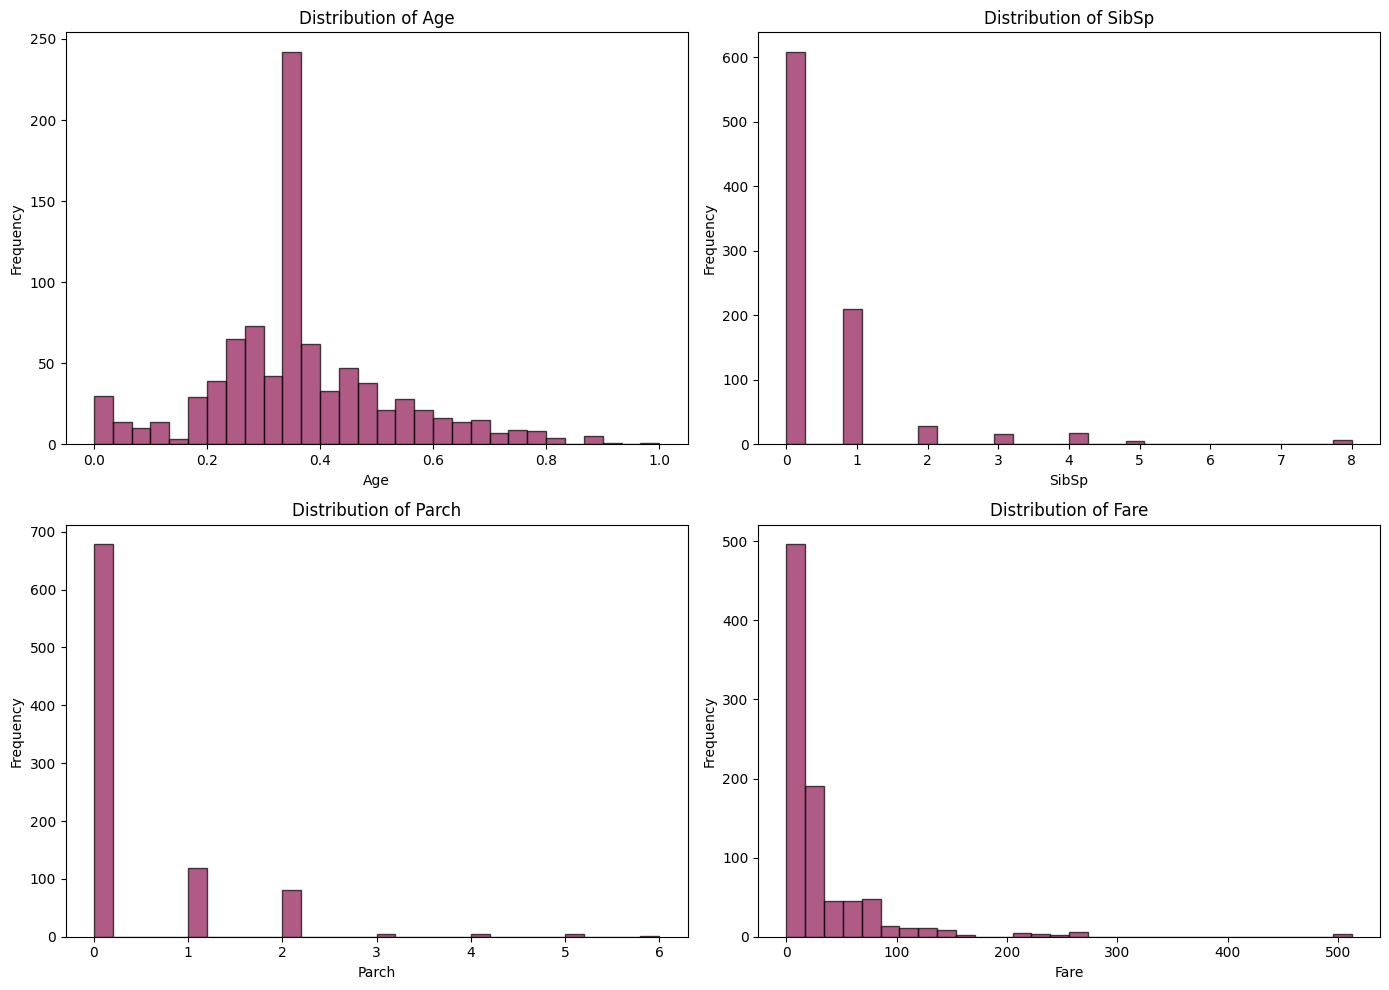

In [5]:


num_features = ['Age', 'SibSp', 'Parch', 'Fare']  # Adjust if Pclass was encoded

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='#8D1651')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('histograms_numeric_features.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mahad\AppData\Local\Temp\ipykernel_20704\4201612191.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([df[col] for col in num_features], labels=num_features, patch_artist=True)


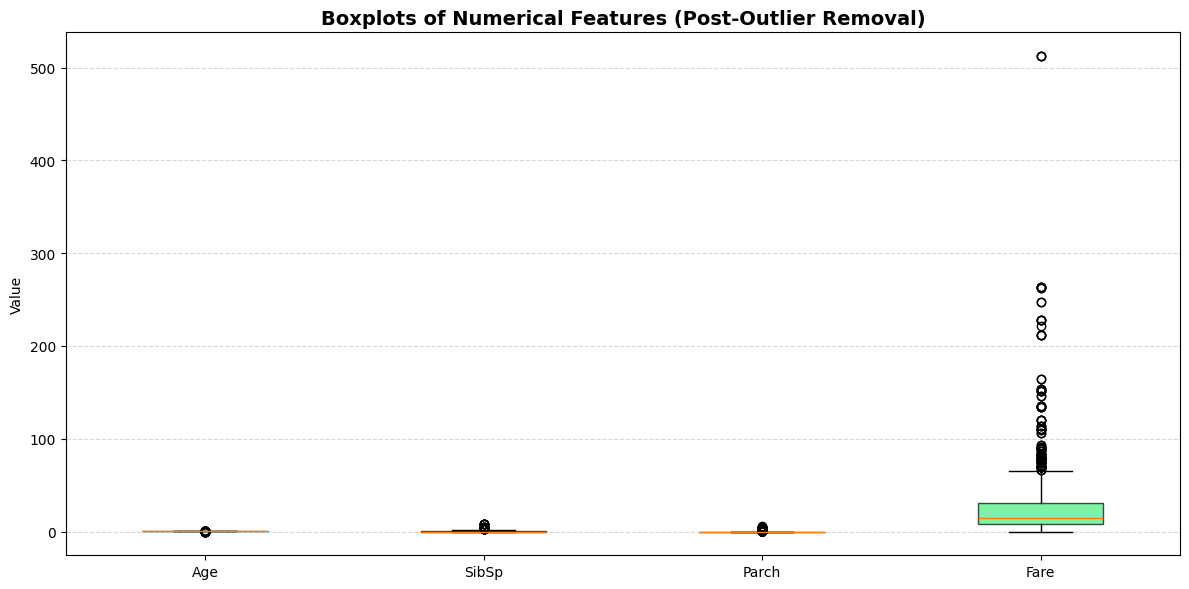

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

box = ax.boxplot([df[col] for col in num_features], labels=num_features, patch_artist=True)

colors = ['#8D1651', '#7D48EE', '#efc6ec', '#48EE7D']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Boxplots of Numerical Features (Post-Outlier Removal)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('boxplots_numeric_features.png', dpi=300, bbox_inches='tight')
plt.show()


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


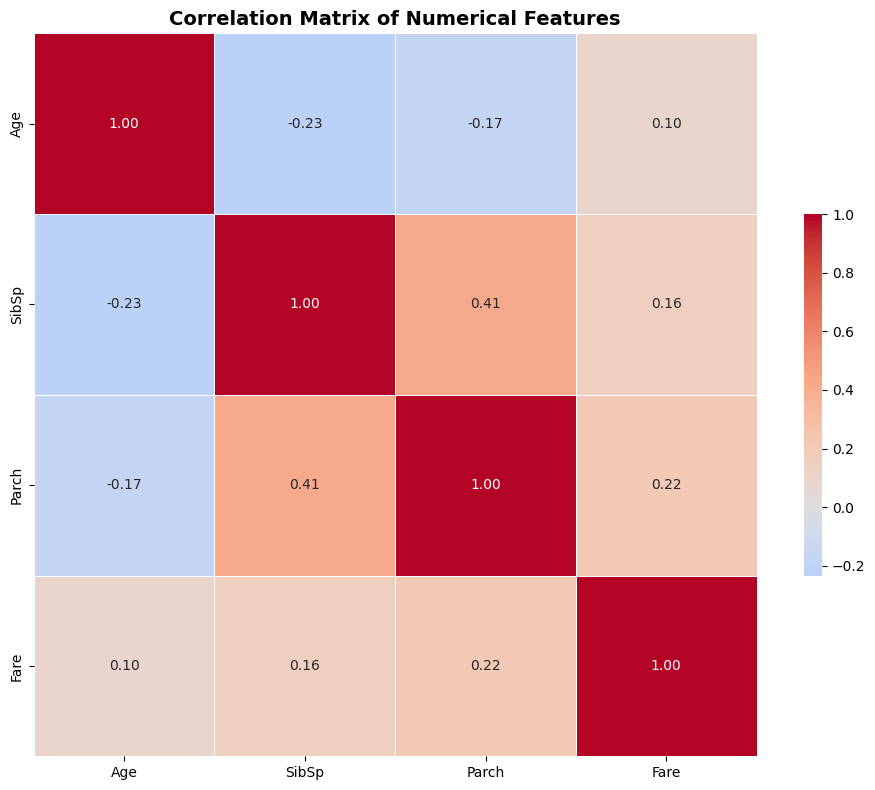

In [10]:
%pip install seaborn

import seaborn as sns


numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']
# Compute correlation matrix (only numeric columns)
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

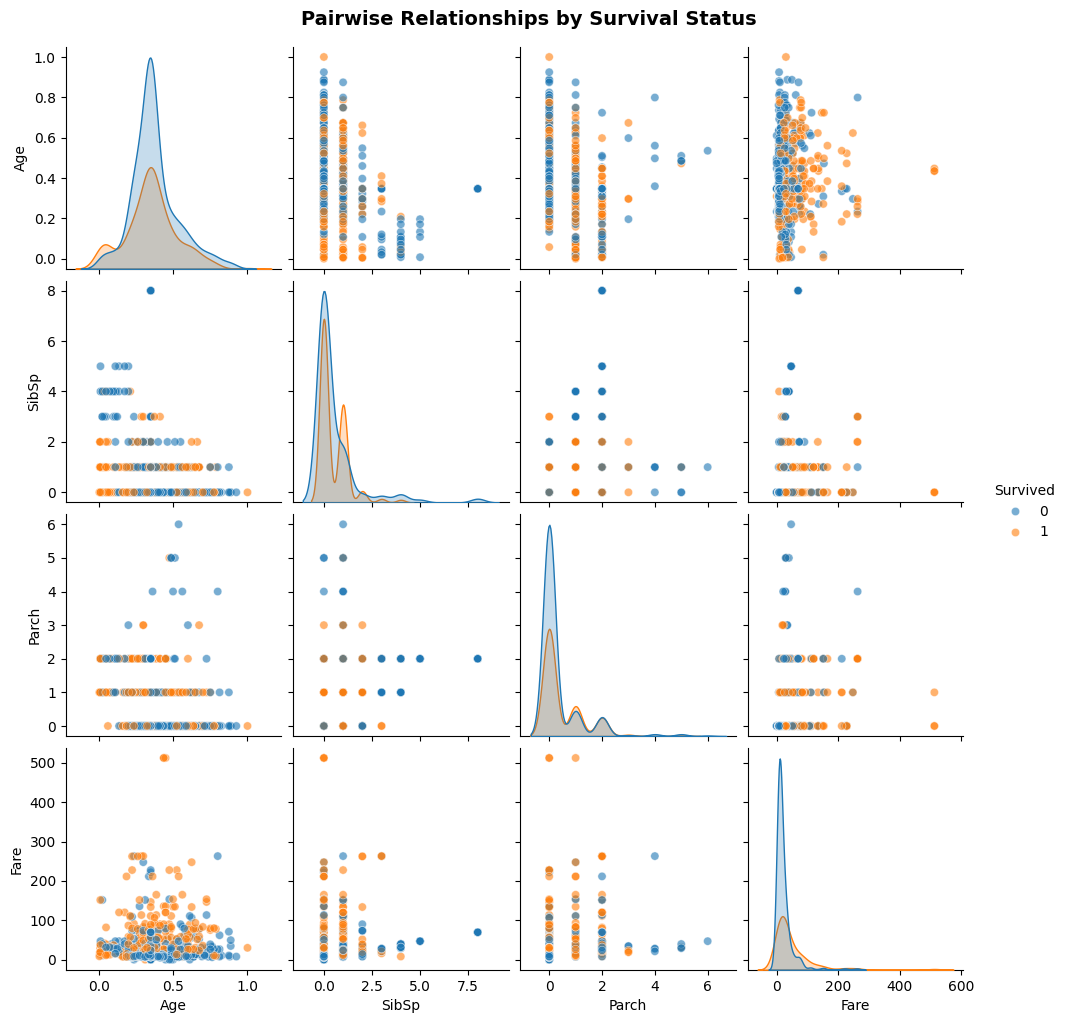

In [12]:
# Use seaborn pairplot for pairwise relationships
g = sns.pairplot(df[numerical_cols + ['Survived']], hue='Survived', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise Relationships by Survival Status', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_by_survival.png', dpi=300, bbox_inches='tight')
plt.show()